In [1]:
import sys
import platform
import traceback

print('Python executable:', sys.executable)
print('Python version:', sys.version.replace('\n',' '))
print('Platform:', platform.platform())

def try_import(name):
    try:
        module = __import__(name)
        ver = getattr(module, '__version__', 'unknown')
        print(f"Imported {name}: version={ver}")
        return module
    except Exception as e:
        print(f"Failed to import {name}: {e}")
        traceback.print_exc()
        return None

tf = try_import('tensorflow')
np = try_import('numpy')
pd = try_import('pandas')
plt = try_import('matplotlib')
sk = try_import('sklearn')
streamlit = try_import('streamlit')
librosa = try_import('librosa')
pillow = try_import('PIL')

if tf is not None:
    try:
        print('TensorFlow version:', tf.__version__)
        print('Physical devices:', tf.config.list_physical_devices())
    except Exception as e:
        print('TensorFlow import succeeded but inspecting devices failed:', e)
        traceback.print_exc()

print('\nDiagnostic cell complete — see above for any failures.')

Python executable: /Users/jasneetsingh/.pyenv/versions/3.11.9/bin/python
Python version: 3.11.9 (main, Dec  2 2025, 09:59:17) [Clang 17.0.0 (clang-1700.4.4.1)]
Platform: macOS-26.1-arm64-arm-64bit
Imported tensorflow: version=2.20.0
Imported numpy: version=2.2.6
Imported pandas: version=2.3.3
Imported matplotlib: version=3.10.7
Failed to import sklearn: No module named 'sklearn'
Failed to import streamlit: No module named 'streamlit'
Failed to import librosa: No module named 'librosa'
Imported PIL: version=12.0.0
TensorFlow version: 2.20.0
Physical devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

Diagnostic cell complete — see above for any failures.


Traceback (most recent call last):
  File "/var/folders/16/qqpzmrys3294wzzrdggbt2480000gn/T/ipykernel_93886/2274689124.py", line 11, in try_import
    module = __import__(name)
             ^^^^^^^^^^^^^^^^
ModuleNotFoundError: No module named 'sklearn'
Traceback (most recent call last):
  File "/var/folders/16/qqpzmrys3294wzzrdggbt2480000gn/T/ipykernel_93886/2274689124.py", line 11, in try_import
    module = __import__(name)
             ^^^^^^^^^^^^^^^^
ModuleNotFoundError: No module named 'streamlit'
Traceback (most recent call last):
  File "/var/folders/16/qqpzmrys3294wzzrdggbt2480000gn/T/ipykernel_93886/2274689124.py", line 11, in try_import
    module = __import__(name)
             ^^^^^^^^^^^^^^^^
ModuleNotFoundError: No module named 'librosa'


## Importing Libraries

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

### Loading Model

In [3]:
# Rebuild the model architecture
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),
    tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.Conv2D(32, (3, 3), padding='valid', activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.Conv2D(64, (3, 3), padding='valid', activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.Conv2D(128, (3, 3), padding='valid', activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.Conv2D(256, (3, 3), padding='valid', activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(512, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.Conv2D(512, (3, 3), padding='valid', activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1500, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(38, activation='softmax')
])

# Load weights
model.load_weights('trained_model.keras')

In [4]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

### Visualizaing Single Image of Test set

In [5]:
%pip install opencv-python


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
import cv2
import os

image_path = "test/test/PotatoHealthy1.JPG"

# Check if file exists
if not os.path.exists(image_path):
	print(f"Error: File not found at {image_path}")
	print(f"Current working directory: {os.getcwd()}")
	print(f"Available files: {os.listdir('.')}")
else:
	#Reading Image
	img = cv2.imread(image_path)
	if img is None:
		print("Error: Failed to read image")
	else:
		img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #Convert BGR image to RGB
		
		#Displaying Image
		plt.imshow(img)
		plt.title("Test Image")
		plt.xticks([])
		plt.yticks([])
		plt.show()

Error: File not found at test/test/PotatoHealthy1.JPG
Current working directory: /Applications/MCA PROJECT/plantDiease
Available files: ['Test_Plant_Disease-2.ipynb', '.DS_Store', 'Train_plant_disease.ipynb', 'home_page.jpeg', 'Plant_Disease_Dataset', 'trained_model.keras', '.venv', 'requirement.txt', 'main.py', 'training_hist.json', 'trained_model.h5']


## Testing Model

In [7]:
import glob

# Ensure the image file exists; if not, try to locate it by filename
filename = os.path.basename(image_path)
if os.path.exists(image_path):
	resolved_path = image_path
else:
	matches = glob.glob(f'**/{filename}', recursive=True)
	if matches:
		resolved_path = matches[0]
		print(f"Found image at {resolved_path}; using that path instead of {image_path}")
	else:
		cwd = os.getcwd()
		top_files = os.listdir(cwd)
		raise FileNotFoundError(
			f"Image not found: {image_path}\nSearched for '{filename}' under {cwd}\n"
			f"Top-level files: {top_files}\nIf the file is elsewhere, move it into the project or update image_path."
		)

# Load and preprocess image
image = tf.keras.preprocessing.image.load_img(resolved_path, target_size=(128, 128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr]) #Convert single image to a batch
print(input_arr.shape)

Found image at Plant_Disease_Dataset/test/test/PotatoHealthy1.JPG; using that path instead of test/test/PotatoHealthy1.JPG
(1, 128, 128, 3)


In [8]:
prediction = model.predict(input_arr)
prediction,prediction.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


(array([[7.23655603e-07, 1.84582881e-04, 4.53611136e-07, 5.55587653e-03,
         7.63474873e-06, 8.94425064e-03, 5.97895719e-02, 3.19461009e-07,
         2.85541751e-06, 5.70054830e-08, 3.53495096e-07, 1.92571474e-06,
         1.77095387e-07, 4.39732560e-07, 5.05526543e-07, 1.19001725e-05,
         6.06723597e-06, 5.15040701e-05, 1.61111078e-04, 3.77536821e-03,
         8.88042359e-06, 5.04740216e-02, 8.70528638e-01, 8.94296591e-06,
         1.17565243e-04, 5.77863446e-08, 5.50678791e-09, 1.02417420e-04,
         1.16172124e-07, 6.73045215e-05, 1.76230693e-04, 1.30054386e-05,
         4.64554688e-07, 2.89635955e-06, 1.01152136e-06, 4.03183890e-07,
         4.90004425e-07, 1.83193231e-06]], dtype=float32),
 (1, 38))

In [9]:
result_index = np.argmax(prediction)
result_index

np.int64(22)

In [10]:
class_name = ['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

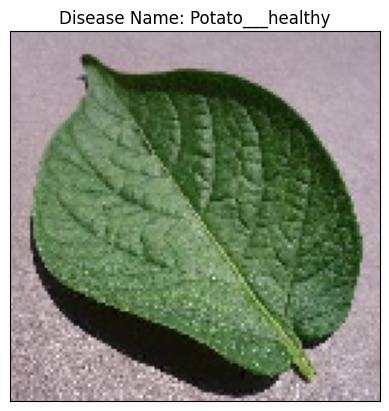

In [11]:
#Displaying Result of disease prediction
model_prediction = class_name[result_index]
plt.imshow(image)
plt.title(f"Disease Name: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()

In [12]:
model_prediction

'Potato___healthy'